# British Airways Reviews — EDA & Sentiment Analysis

**Goal:** Explore the cleaned BA reviews dataset, answer key analytical questions through visualisations, and analyse review sentiment.

## Notebook Structure
1. [Setup & Imports](#1-setup--imports)
2. [Load Data](#2-load-data)
3. [Feature Engineering](#3-feature-engineering)
4. [EDA — Rating Distribution](#4-eda--rating-distribution)
5. [EDA — Review Length Analysis](#5-eda--review-length-analysis)
6. [EDA — Most Frequent Words](#6-eda--most-frequent-words)
7. [EDA — Word Cloud](#7-eda--word-cloud)
8. [Sentiment Analysis](#8-sentiment-analysis)
9. [Topic Modelling (LDA)](#9-topic-modelling-lda)

---
## 1. Setup & Imports

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import re
from collections import Counter

# ── Data manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import wordcloud as wc

# ── NLP ───────────────────────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords

# ── Machine learning ──────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Download required NLTK data (run once, then comment out)
# nltk.download('stopwords')

# Global plot style
sns.set_theme(style="darkgrid")

---
## 2. Load Data

Load the pre-cleaned dataset produced by the **collection & cleaning** notebook.

In [2]:
# Load the cleaned reviews CSV (relative path from notebooks/ folder)
df = pd.read_csv("../data/clean_BA_reviews.csv")

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (3595, 4)


,Unnamed: 0,original_review,ratings,clean_review
0,0,Not Verified | British Airways has confirmed ...,1.0,not confirmed worst uk last minute cancellatio...
1,1,✅ Trip Verified | Worst BA experience. I was s...,2.0,worst experience supposed fly italy september ...
2,2,✅ Trip Verified | My daughter and I were deni...,1.0,daughter denied boarding business class madrid...
3,3,✅ Trip Verified | Despite boarding being the u...,8.0,despite boarding usual free lhr groups called ...
4,4,"Not Verified | Flight cancelled, no crew! 9th...",1.0,not cancelled no crew september not peak holid...


In [3]:
# ── Stopword list (mirrors the cleaning notebook) ─────────────────────────────
# We keep 'not' and 'no' because they carry sentiment signal.
nltk_stop_words = stopwords.words("english")

domain_words = [
    "flight", "british", "airway", "airways",
    "ba", "airline", "seat", "seats",
    "one", "trip", "verified", "not",
]
nltk_stop_words.extend(domain_words)

# Keep negations for sentiment analysis
for negation in ["not", "no"]:
    if negation in nltk_stop_words:
        nltk_stop_words.remove(negation)

print(f"Total stopwords: {len(nltk_stop_words)}")
print("Sample:", nltk_stop_words[:10])

Total stopwords: 189
Sample: ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're"]


---
## 3. Feature Engineering

Derive additional columns that will be used throughout the analysis:

| Column | Description |
|--------|-------------|
| `rating_interpretation` | Binary sentiment label: **positive** (rating ≥ 7) / **negative** (rating < 7) |
| `text_len` | Character length of the original review |
| `text_word_count` | Word count of the cleaned review |

In [4]:
# ── Sentiment label based on star rating ──────────────────────────────────────
# Skytrax uses a 1-10 scale.
# Threshold: ratings 7-10 → positive, 1-6 → negative.
# This gives a simple binary target for classification tasks.
df["rating_interpretation"] = df["ratings"].apply(
    lambda r: "positive" if r >= 7 else "negative"
)

# ── Text length features ──────────────────────────────────────────────────────
df["text_len"]        = df["original_review"].str.len()   # character count
df["text_word_count"] = df["clean_review"].str.split().str.len()  # word count (post-clean)

print("New columns added: rating_interpretation, text_len, text_word_count")
df.head()

New columns added: rating_interpretation, text_len, text_word_count


,Unnamed: 0,original_review,ratings,clean_review,rating_interpretation,text_len,text_word_count
0,0,Not Verified | British Airways has confirmed ...,1.0,not confirmed worst uk last minute cancellatio...,negative,270,18
1,1,✅ Trip Verified | Worst BA experience. I was s...,2.0,worst experience supposed fly italy september ...,negative,1431,119
2,2,✅ Trip Verified | My daughter and I were deni...,1.0,daughter denied boarding business class madrid...,negative,1987,162
3,3,✅ Trip Verified | Despite boarding being the u...,8.0,despite boarding usual free lhr groups called ...,positive,647,59
4,4,"Not Verified | Flight cancelled, no crew! 9th...",1.0,not cancelled no crew september not peak holid...,negative,295,24


---
## 4. EDA — Rating Distribution

**Q: How are star ratings distributed across reviews?**  
Understanding the rating distribution reveals overall customer satisfaction levels and class imbalance for any supervised learning task.

In [5]:
# ── Overall rating distribution (histogram) ───────────────────────────────────
fig = px.histogram(
    df,
    x="ratings",
    color="rating_interpretation",
    nbins=10,
    title="Distribution of Star Ratings (1–10)",
    labels={"ratings": "Star Rating", "count": "Number of Reviews"},
    color_discrete_map={"positive": "#2ecc71", "negative": "#e74c3c"},
)
fig.update_layout(bargap=0.1)
fig.show()

In [6]:
# ── Positive vs. Negative split (pie chart) ───────────────────────────────────
sentiment_counts = df["rating_interpretation"].value_counts().reset_index()
sentiment_counts.columns = ["sentiment", "count"]

fig = px.pie(
    sentiment_counts,
    values="count",
    names="sentiment",
    title="Positive vs. Negative Reviews",
    color="sentiment",
    color_discrete_map={"positive": "#2ecc71", "negative": "#e74c3c"},
)
fig.show()

# Print summary
total = sentiment_counts["count"].sum()
for _, row in sentiment_counts.iterrows():
    print(f"{row['sentiment'].capitalize():10s}: {row['count']} ({row['count']/total*100:.1f}%)")

Negative  : 2305 (64.1%)
Positive  : 1290 (35.9%)


---
## 5. EDA — Review Length Analysis

**Q: Do positive and negative reviewers write differently in terms of length?**  
Longer reviews may indicate stronger opinions (positive or negative).

In [7]:
# ── Box plot: review character length by sentiment ────────────────────────────
fig = px.box(
    df,
    x="rating_interpretation",
    y="text_len",
    color="rating_interpretation",
    title="Review Character Length by Sentiment",
    labels={"text_len": "Character Count", "rating_interpretation": "Sentiment"},
    color_discrete_map={"positive": "#2ecc71", "negative": "#e74c3c"},
)
fig.show()

In [8]:
# ── Histogram: word count distribution ───────────────────────────────────────
fig = px.histogram(
    df,
    x="text_word_count",
    color="rating_interpretation",
    nbins=40,
    title="Word Count Distribution by Sentiment (Cleaned Reviews)",
    labels={"text_word_count": "Word Count", "count": "Number of Reviews"},
    color_discrete_map={"positive": "#2ecc71", "negative": "#e74c3c"},
    barmode="overlay",
    opacity=0.7,
)
fig.show()

# Summary statistics
print(df.groupby("rating_interpretation")[["text_len", "text_word_count"]].describe().round(1))

                      text_len                                             \
                         count   mean    std    min    25%    50%     75%   
rating_interpretation                                                       
negative                2305.0  974.4  597.3  149.0  553.0  832.0  1218.0   
positive                1290.0  748.8  496.6   83.0  413.0  618.5   927.8   

                              text_word_count                               \
                          max           count  mean   std  min   25%   50%   
rating_interpretation                                                        
negative               3537.0          2305.0  84.9  52.0  9.0  48.0  73.0   
positive               3508.0          1290.0  67.1  45.4  9.0  36.0  55.0   

                                     
                         75%    max  
rating_interpretation                
negative               106.0  348.0  
positive                83.0  357.0  


---
## 6. EDA — Most Frequent Words

**Q: What are the most commonly used words in the reviews?**  
Frequency analysis helps identify dominant themes and validates that the stopword removal worked correctly.

In [9]:
# ── Compute word frequencies across all clean reviews ─────────────────────────
# Join all reviews into one large string, then tokenise
all_text = " ".join(df["clean_review"].tolist())
words     = re.findall(r"\w+", all_text.lower())

# Count and convert to a ranked DataFrame
word_freq = Counter(words)
word_freq_df = (
    pd.DataFrame.from_dict(word_freq, orient="index", columns=["frequency"])
    .sort_values("frequency", ascending=False)
    .reset_index()
    .rename(columns={"index": "word"})
)

print(f"Unique words: {len(word_freq_df)}")
word_freq_df.head(20)

Unique words: 13777


,word,frequency
0,not,4590
1,no,2905
2,service,2753
3,food,2288
4,london,2150
5,crew,2086
6,good,2028
7,time,1986
8,cabin,1919
9,class,1836


In [10]:
# ── Bar chart: top 20 most frequent words ────────────────────────────────────
top_n = 20
top_words = word_freq_df.head(top_n)

fig = px.bar(
    top_words,
    x="word",
    y="frequency",
    color="frequency",
    color_continuous_scale="Blues",
    title=f"Top {top_n} Most Frequent Words in Cleaned Reviews",
    labels={"word": "Word", "frequency": "Frequency"},
)
fig.update_layout(xaxis_tickangle=-30)
fig.show()

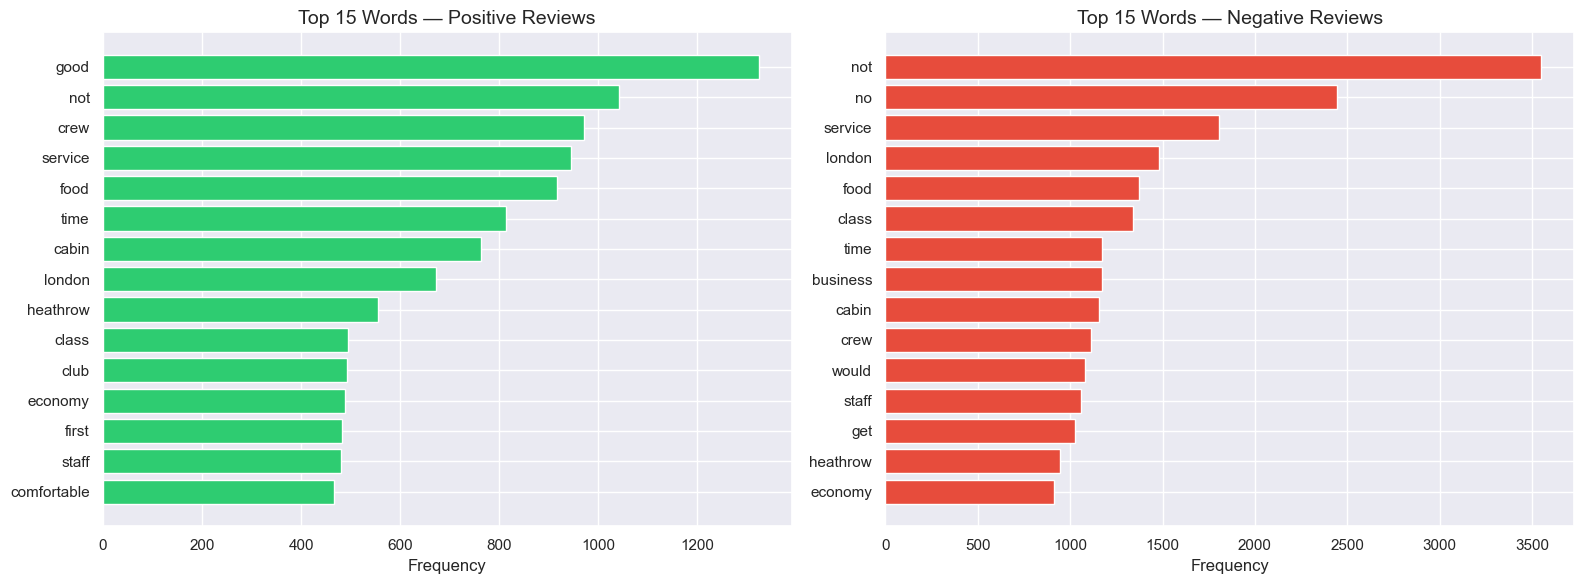

In [11]:
# ── Top words split by sentiment ──────────────────────────────────────────────
# This reveals which words characterise positive vs. negative reviews

def top_words_for_sentiment(sentiment: str, n: int = 15) -> pd.DataFrame:
    """Return the n most frequent words for a given sentiment group."""
    subset = df[df["rating_interpretation"] == sentiment]["clean_review"]
    text   = " ".join(subset.tolist())
    words  = re.findall(r"\w+", text.lower())
    counts = Counter(words)
    return (
        pd.DataFrame.from_dict(counts, orient="index", columns=["frequency"])
        .sort_values("frequency", ascending=False)
        .reset_index()
        .rename(columns={"index": "word"})
        .head(n)
    )

positive_words = top_words_for_sentiment("positive")
negative_words = top_words_for_sentiment("negative")

# Side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(positive_words["word"][::-1], positive_words["frequency"][::-1], color="#2ecc71")
axes[0].set_title("Top 15 Words — Positive Reviews", fontsize=14)
axes[0].set_xlabel("Frequency")

axes[1].barh(negative_words["word"][::-1], negative_words["frequency"][::-1], color="#e74c3c")
axes[1].set_title("Top 15 Words — Negative Reviews", fontsize=14)
axes[1].set_xlabel("Frequency")

plt.tight_layout()
plt.show()

---
## 7. EDA — Word Cloud

Word clouds provide a fast visual impression of dominant vocabulary across all reviews and per sentiment group.

In [12]:
# ── Word cloud — all reviews ──────────────────────────────────────────────────
all_clean_text = " ".join(df["clean_review"].tolist())

# Extra suppressions: Skytrax artefacts that survived cleaning
extra_suppressions = nltk_stop_words + ["no", "not", "trip", "ba", "verified"]

cloud = wc.WordCloud(
    width=1200,
    height=600,
    stopwords=extra_suppressions,
    background_color="white",
    colormap="viridis",
    max_words=200,
).generate(all_clean_text)

fig = px.imshow(cloud, width=900, height=450, title="Word Cloud — All Reviews")
fig.update_layout(coloraxis_showscale=False)
fig.show()

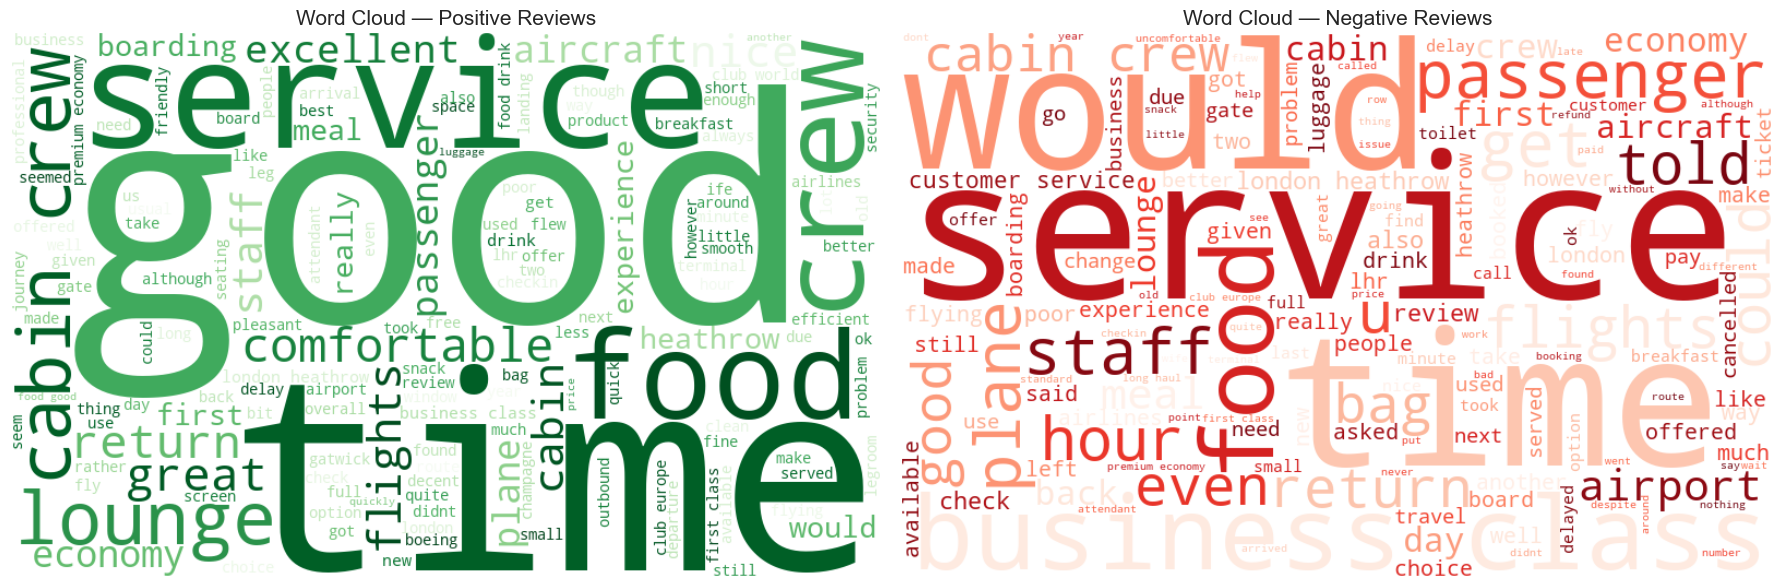

In [13]:
# ── Word clouds split by sentiment ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, sentiment, cmap in zip(
    axes,
    ["positive", "negative"],
    ["Greens", "Reds"]
):
    text = " ".join(
        df[df["rating_interpretation"] == sentiment]["clean_review"].tolist()
    )
    cloud = wc.WordCloud(
        width=800, height=500,
        stopwords=extra_suppressions,
        background_color="white",
        colormap=cmap,
        max_words=150,
    ).generate(text)

    ax.imshow(cloud, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Word Cloud — {sentiment.capitalize()} Reviews", fontsize=15)

plt.tight_layout()
plt.show()

---
## 8. Sentiment Analysis

We use **TF-IDF** (Term Frequency–Inverse Document Frequency) to weight words by their
importance across the corpus, then inspect the most discriminative terms for each sentiment class.

TF-IDF gives higher scores to words that are frequent in a review but rare across the whole corpus,
making it better than raw counts for identifying meaningful signal.

In [14]:
# ── TF-IDF vectorisation ──────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=500,          # Keep the 500 most informative terms
    stop_words=nltk_stop_words,
    ngram_range=(1, 2),        # Include unigrams and bigrams
    min_df=5,                  # Ignore terms appearing in fewer than 5 reviews
)

tfidf_matrix = tfidf.fit_transform(df["clean_review"])
tf_feature_names = np.array(tfidf.get_feature_names_out())

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Number of features: {len(tf_feature_names)}")
print("Sample features:", tf_feature_names[:20])

TF-IDF matrix shape: (3595, 500)
Number of features: 500
Sample features: ['able' 'absolutely' 'access' 'actually' 'agent' 'ago' 'air' 'aircraft'
 'airlines' 'airport' 'aisle' 'allowed' 'almost' 'already' 'also'
 'although' 'always' 'another' 'anything' 'area']


In [15]:
# ── Top TF-IDF terms per sentiment class ──────────────────────────────────────
# Average TF-IDF score for each term within each sentiment group.
# Terms with high average TF-IDF are most characteristic of that group.

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tf_feature_names
)
tfidf_df["sentiment"] = df["rating_interpretation"].values

# Compute per-group mean TF-IDF for each term
mean_tfidf = tfidf_df.groupby("sentiment").mean()

# Display top 15 terms for each sentiment
top_n = 15
for sentiment in ["positive", "negative"]:
    top_terms = (
        mean_tfidf.loc[sentiment]
        .sort_values(ascending=False)
        .head(top_n)
    )
    print(f"\n🔹 Top {top_n} TF-IDF terms for {sentiment.upper()} reviews:")
    print(top_terms.to_string())


🔹 Top 15 TF-IDF terms for POSITIVE reviews:
good           0.089646
crew           0.063617
food           0.054176
service        0.052904
time           0.051006
cabin          0.049985
excellent      0.045729
comfortable    0.044385
great          0.043482
london         0.041940
heathrow       0.040007
friendly       0.039505
club           0.037513
economy        0.035965
nice           0.035865

🔹 Top 15 TF-IDF terms for NEGATIVE reviews:
no                0.065674
service           0.048570
class             0.044635
london            0.042904
business          0.041811
food              0.039762
staff             0.036669
cabin             0.035501
get               0.034225
time              0.033730
would             0.033417
business class    0.033353
economy           0.033062
crew              0.032823
heathrow          0.032578


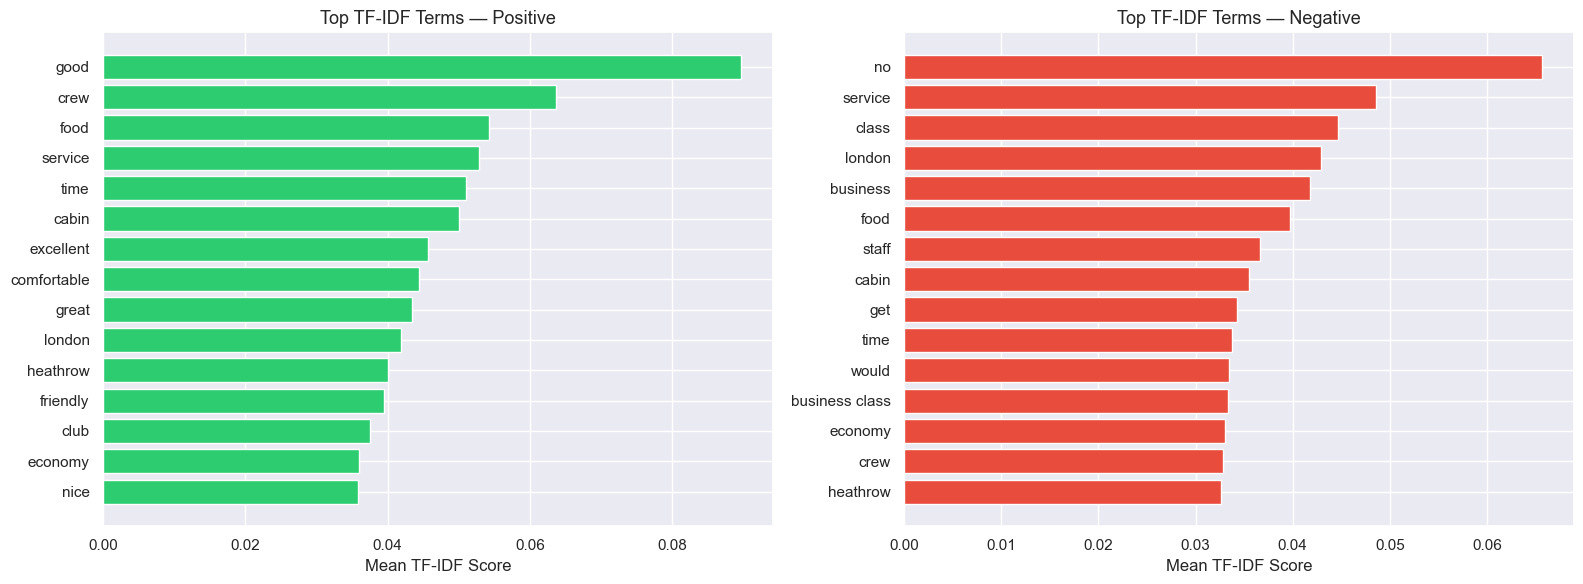

In [16]:
# ── Visualise top TF-IDF terms per sentiment ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, sentiment, color in zip(
    axes,
    ["positive", "negative"],
    ["#2ecc71", "#e74c3c"]
):
    top_terms = (
        mean_tfidf.loc[sentiment]
        .sort_values(ascending=False)
        .head(15)
    )
    ax.barh(top_terms.index[::-1], top_terms.values[::-1], color=color)
    ax.set_title(f"Top TF-IDF Terms — {sentiment.capitalize()}", fontsize=13)
    ax.set_xlabel("Mean TF-IDF Score")

plt.tight_layout()
plt.show()

---
## 9. Topic Modelling (LDA)

**Latent Dirichlet Allocation (LDA)** is an unsupervised algorithm that discovers latent topics
in a collection of documents. Each topic is represented by a distribution over words, and each
review is a mixture of topics.

This helps us understand *what themes* customers write about — e.g., delays, food quality, staff behaviour.

In [17]:
# ── Count vectorisation for LDA ───────────────────────────────────────────────
# LDA works with raw term counts (not TF-IDF weights)
count_vec = CountVectorizer(
    max_features=1000,         # Vocabulary size
    stop_words=nltk_stop_words,
    min_df=5,
    ngram_range=(1, 1),        # Unigrams only for interpretable topics
)

count_matrix = count_vec.fit_transform(df["clean_review"])
count_feature_names = np.array(count_vec.get_feature_names_out())

print(f"Count matrix shape: {count_matrix.shape}")

Count matrix shape: (3595, 1000)


In [18]:
# ── Fit LDA model ─────────────────────────────────────────────────────────────
N_TOPICS = 5     # Number of latent topics to discover
N_TOP_WORDS = 10 # Number of top words to display per topic

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    learning_method="batch",   # 'batch' is slower but more stable for small datasets
    max_iter=20,
)
lda.fit(count_matrix)

print(f"LDA model fitted with {N_TOPICS} topics.")

LDA model fitted with 5 topics.


In [19]:
# ── Display top words per topic ───────────────────────────────────────────────
# Each row in lda.components_ represents one topic,
# and the values are the (unnormalised) word weights.

print(f"Top {N_TOP_WORDS} words per topic:\n")
for topic_idx, topic_weights in enumerate(lda.components_):
    # Get indices of the N_TOP_WORDS highest-weight words for this topic
    top_word_indices = topic_weights.argsort()[-N_TOP_WORDS:][::-1]
    top_words_list   = count_feature_names[top_word_indices]
    print(f"  Topic {topic_idx + 1}: {', '.join(top_words_list)}")

Top 10 words per topic:

  Topic 1: good, club, lounge, crew, service, food, cabin, time, first, world
  Topic 2: customer, no, service, told, would, get, london, us, booked, cancelled
  Topic 3: class, business, no, economy, food, service, cabin, get, premium, meal
  Topic 4: service, good, london, crew, food, flights, heathrow, cabin, time, aircraft
  Topic 5: no, staff, boarding, luggage, check, passengers, time, minutes, delayed, hours


In [20]:
# ── Heatmap: topic-word weight matrix ────────────────────────────────────────
# Shows how strongly each top word is associated with each topic

# Collect top words across all topics (union of top-10 per topic)
all_top_indices = set()
for topic_weights in lda.components_:
    all_top_indices.update(topic_weights.argsort()[-N_TOP_WORDS:])

all_top_indices = sorted(all_top_indices)
heatmap_words   = count_feature_names[all_top_indices]

# Extract the sub-matrix of weights for these words
heatmap_data = pd.DataFrame(
    lda.components_[:, all_top_indices],
    index=[f"Topic {i+1}" for i in range(N_TOPICS)],
    columns=heatmap_words,
)

fig = px.imshow(
    heatmap_data,
    color_continuous_scale="Blues",
    title="LDA Topic–Word Weight Heatmap",
    labels={"x": "Word", "y": "Topic", "color": "Weight"},
    aspect="auto",
)
fig.update_xaxes(tickangle=-40)
fig.update_layout(height=400)
fig.show()

In [21]:
# ── Assign dominant topic to each review ─────────────────────────────────────
# Transform gives an (n_docs x n_topics) matrix of topic proportions per review
doc_topic_matrix = lda.transform(count_matrix)

# The dominant topic is the one with the highest proportion
df["dominant_topic"] = doc_topic_matrix.argmax(axis=1) + 1  # 1-indexed

# Distribution of dominant topics
topic_dist = df["dominant_topic"].value_counts().sort_index().reset_index()
topic_dist.columns = ["topic", "count"]

fig = px.bar(
    topic_dist,
    x="topic",
    y="count",
    color="topic",
    title="Number of Reviews per Dominant Topic",
    labels={"topic": "Topic Number", "count": "Review Count"},
)
fig.show()

print("\nReview counts per dominant topic:")
print(topic_dist.to_string(index=False))


Review counts per dominant topic:
 topic  count
     1    722
     2    539
     3   1118
     4    775
     5    441


---
## 10. Summary & Key Findings

This notebook explored the British Airways review dataset and transformed raw text into a structured analysis workflow.

### What the analysis shows
- The rating distribution highlights the overall sentiment balance in the dataset and helps assess whether the sample is skewed toward positive or negative feedback.
- Review length analysis shows whether more detailed comments are associated with stronger positive or negative opinions.
- Word-frequency and word-cloud analysis reveal the most repeated themes in traveller feedback, such as service, comfort, punctuality, or cabin experience.
- TF-IDF analysis identifies the terms most strongly associated with each sentiment group, helping translate raw complaints and praise into actionable insights.
- Topic modelling uncovers latent themes across the review corpus, allowing the team to group customer feedback into recurring patterns.

### Business interpretation
These findings help British Airways identify the strongest drivers of customer satisfaction and dissatisfaction. The most common pain points can be prioritised for service improvement, while recurring positive themes can be reinforced in customer experience strategy.

### Next steps
1. Validate the sentiment signal against customer ratings.
2. Compare the most frequent topics with operational KPIs.
3. Extend the analysis with more advanced models such as supervised sentiment classification or aspect-based sentiment analysis.


In [22]:
# ── Save the enriched dataset ─────────────────────────────────────────────────
# Include all engineered features and the dominant topic label
df.to_csv("../outputs/BA_reviews_sentiment_analysis.csv", index=False)
print(f"Final dataset saved: {df.shape[0]} rows, {df.shape[1]} columns")
print("Columns:", list(df.columns))

Final dataset saved: 3595 rows, 8 columns
Columns: ['Unnamed: 0', 'original_review', 'ratings', 'clean_review', 'rating_interpretation', 'text_len', 'text_word_count', 'dominant_topic']
